# Multiple Regression Analysis using Scikit-Learn

This project demonstrates how to build a multiple regression model using Python and scikit-learn.

## Objective
Predict student scores based on study hours.

## Tools Used
- Python
- pandas
- numpy
- scikit-learn
- matplotlib

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Load Dataset

In [21]:
data = pd.read_csv("C:\\Users\\steve\\Documents\\Datasets\\Raw\\boston_house_prices\\Boston-house-price-data.csv")
print(data.head())
print(data.columns)
print(data.shape)
print(data.isnull().sum())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')
(506, 14)
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


## Data Exploration

In [22]:
print(data.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

## Define Features and Target

In [23]:
x = data[['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD']]
y = data['TAX']

## Split the Dataset

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=41
)

## Train the Model

In [25]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Coefficients

In [26]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print(f"Intercept: {model.intercept_:.2f}")

  Feature  Coefficient
0    CRIM     0.178293
1   INDUS     6.948619
2     NOX    49.956696
3      RM    -4.999541
4     AGE     0.044929
5     DIS     5.293413
6     RAD    14.360589
Intercept: 172.92


## Make Predictions

In [27]:
y_pred = model.predict(x_test)

## Model Evaluation

In [28]:
print("Mean Absolute Error:", round(metrics.mean_absolute_error(y_test, y_pred), 2))
print("Mean Squared Error:", round(metrics.mean_squared_error(y_test, y_pred), 2))
print("R2 Score:", round(metrics.r2_score(y_test, y_pred), 2))

Mean Absolute Error: 41.13
Mean Squared Error: 4845.02
R2 Score: 0.84


## Model Performance

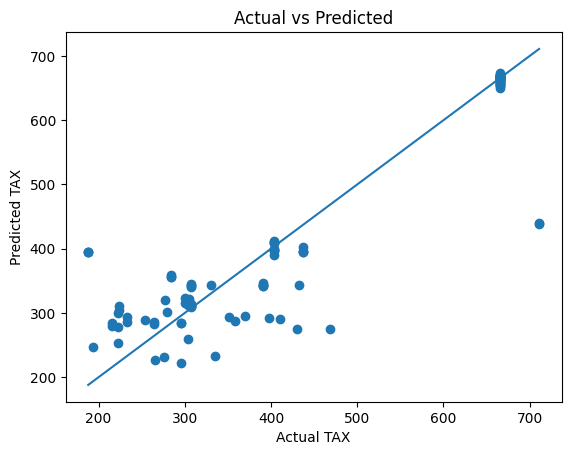

In [29]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual TAX")
plt.ylabel("Predicted TAX")
plt.title("Actual vs Predicted")
plt.show()

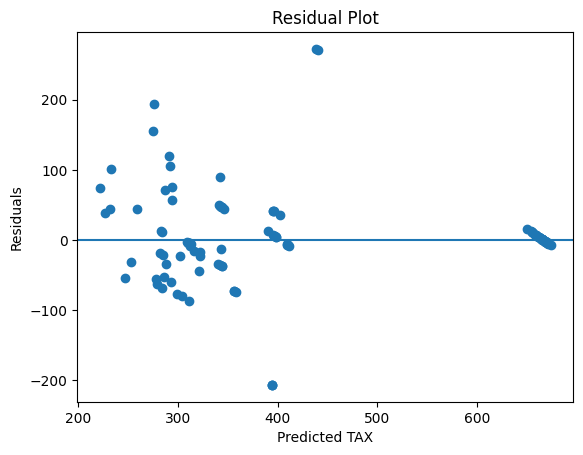

In [30]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted TAX")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Predict New Property Tax Value

Using the trained model to predict TAX based on new input values.

In [31]:
new_data = pd.DataFrame({
    'CRIM': [0.10],
    'INDUS': [7.50],
    'NOX': [0.50],
    'RM': [6.20],
    'AGE': [65.0],
    'DIS': [4.10],
    'RAD': [5]
})

### Input Explanation

The values above represent a hypothetical town with:
- Low crime rate
- Moderate industrial activity
- Average number of rooms
- متوسط distance to employment centres

The model estimates the corresponding property tax rate.

In [32]:
prediction = model.predict(new_data)

print(f"Predicted TAX: {prediction[0]:.2f}")

result_df = new_data.copy()
result_df['Predicted TAX'] = prediction

result_df

Predicted TAX: 315.46


,CRIM,INDUS,NOX,RM,AGE,DIS,RAD,Predicted TAX
0,0.1,7.5,0.5,6.2,65.0,4.1,5,315.463836
